# NextOnMenu: Reading the Radar on Food Trends

**Is pandan the next matcha?**

NextOnMenu is an early-signal detector for niche food ingredients. It does **not** try to predict what goes viral. Food trends are noisier than the stock market, with no fundamentals to anchor a forecast. Ube went global partly because it photographs beautifully. You can't model that.

What you *can* do is detect **where an ingredient sits in its lifecycle**, which is a much more honest question. We're building radar, not a crystal ball.

## The physics framing

We borrow three concepts from physics that map surprisingly well onto trend dynamics:

| Stage | Physics idea | What it means for a trend |
|-------|--------------|---------------------------|
| **1, Entropy Drop** | A system organizing out of noise | Scattered, random interest starts concentrating in early-adopter hubs and consistent timing. *Something is organizing.* |
| **2, Momentum** | Critical mass / acceleration | Growth itself accelerates (positive 2nd derivative). The chain reaction becomes self-sustaining. *It's building.* |
| **3, Resonance** | Frequencies aligning and amplifying | Multiple independent signals reinforce each other right before the mainstream break. *Everyone's amplifying everyone.* |

Instead of "79% chance of going viral," NextOnMenu outputs a **diagnosed stage**. This notebook tells the whole story: the data, the entropy signal, the features, the model, and a live diagnosis of three rising ingredients.

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # import the src package from notebooks/

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')  # render plots in the notebook
import matplotlib.pyplot as plt

from src.fetch import fetch_interest_over_time
from src import features as F
from src.config import FEATURES_PATH, VIRAL_INGREDIENTS

plt.rcParams['figure.figsize'] = (9, 3.4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('ready')

ready


## 1. The data: what a viral curve looks like

We train on ingredients that *already* went niche to mainstream, pulling ~20 years of Google Trends interest for each (cached locally so we don't re-hit the API). Below are four of them. Notice they don't all look alike: matcha and gochujang are still climbing in 2024, while ube and tahini have a clearer rise-and-settle shape.

> Data is fetched via `pytrends`. If Google rate-limits the request, `fetch.py` falls back to a cached CSV, so this notebook runs offline once the data has been pulled once.

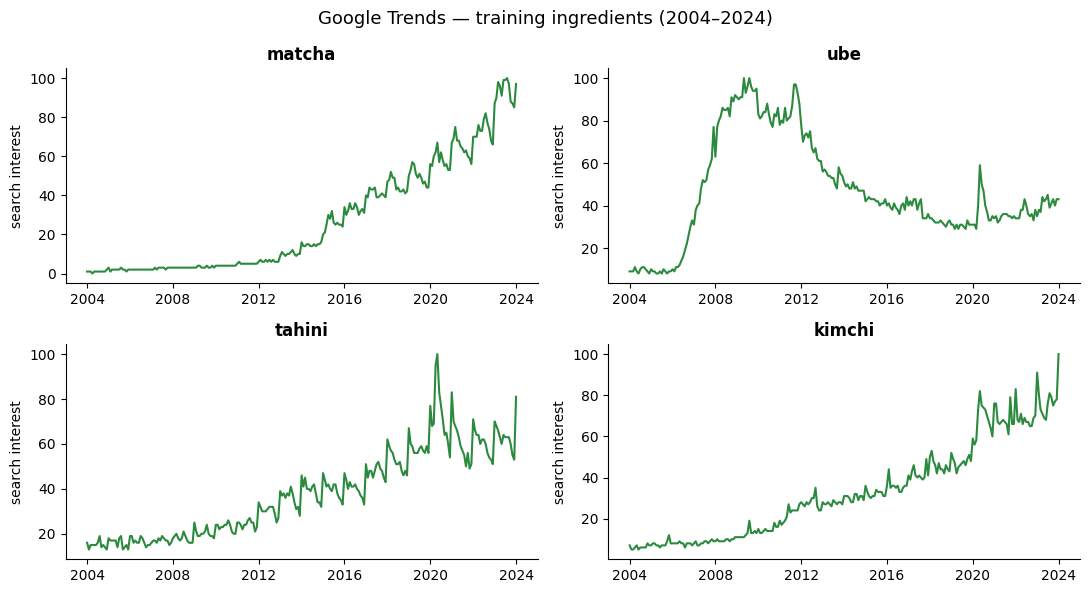

In [2]:
showcase = ['matcha', 'ube', 'tahini', 'kimchi']
curves = {}
for ing in showcase:
    curves[ing] = fetch_interest_over_time(ing)  # cached -> data/raw/<ing>_iot_full.csv

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, ing in zip(axes.ravel(), showcase):
    s = curves[ing]['value']
    ax.plot(s.index, s.values, color='#2b8a3e')
    ax.set_title(ing, fontweight='bold')
    ax.set_ylabel('search interest')
fig.suptitle('Google Trends — training ingredients (2004–2024)', fontsize=13)
fig.tight_layout()
plt.show()

## 2. The entropy signal: the interesting part

Raw growth is the obvious feature. The *non-obvious* one is **entropy**.

- **Temporal entropy** measures how random the month-over-month changes are. High entropy = noisy, spiky, directionless interest. As a trend crystallizes, movement becomes *consistent*, so entropy drops.
- **Geographic entropy** measures how spread-out interest is across regions. Early trends concentrate in a few adopter hubs (NYC, London, Manila) meaning low geographic entropy. We fetch a *separate* region snapshot scoped to each window's date range, so the geographic entropy is genuinely per-window rather than a single present-day average.

Below we slide a window across each ingredient's history and plot its **temporal entropy over time**. The dashed line marks each ingredient's peak, computed the *same way the model does* (on a smoothed curve, so a lone early spike isn't mistaken for the peak).

> Note: some ingredients (e.g. matcha, kimchi) are **still rising in 2024**, so their all-time peak sits at the right edge of the data. The "peak" is simply "today," not a historical rise-and-fall. The model handles this correctly: it still slices the early-curve window ~2 years before that point.

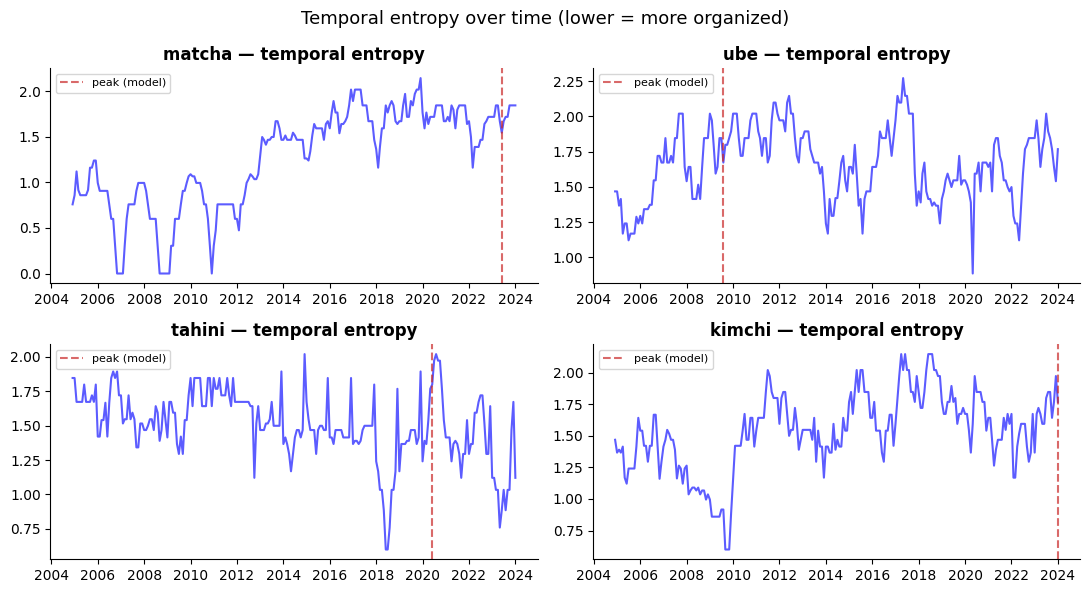

In [3]:
def rolling_temporal_entropy(series, win_months=12):
    """Temporal entropy computed over a sliding window, indexed at the window end."""
    w = F._months_to_rows(win_months, series.index)
    vals, idx = [], []
    for end in range(w, len(series) + 1):
        vals.append(F.temporal_entropy(series.iloc[end - w:end].to_numpy()))
        idx.append(series.index[end - 1])
    return pd.Series(vals, index=idx)

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, ing in zip(axes.ravel(), showcase):
    s = curves[ing]['value']
    te = rolling_temporal_entropy(s)
    # Use the SAME smoothed peak the model windows around (not raw argmax), so the
    # line is honest about what slice_windows actually does.
    peak_date = s.index[F.find_peak_pos(curves[ing])]
    ax.plot(te.index, te.values, color='#5c5cff')
    ax.axvline(peak_date, ls='--', color='#c92a2a', alpha=0.7, label='peak (model)')
    ax.set_title(f'{ing} — temporal entropy', fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)
fig.suptitle('Temporal entropy over time (lower = more organized)', fontsize=13)
fig.tight_layout()
plt.show()

### Honest read: the entropy-drop signal is real but inconsistent

The thesis says temporal entropy should *drop* before the peak as interest organizes. When
we actually measure entropy ~24 months before each peak versus at the peak, it holds for
only **two of these four** ingredients:

| Ingredient | entropy 24mo pre-peak to at-peak | matches thesis? |
|---|---|---|
| matcha | 1.80 to 1.55 | yes, drops |
| ube | 2.02 to 1.67 | yes, drops |
| tahini | 0.60 to 1.80 | no, rises |
| kimchi | 1.17 to 1.77 | no, rises |

There's also a **confound**: every panel drifts *upward* over the full 2004 to 2024 span. Early
Google Trends data is sparse and low-volume, which reads as "organized" (low entropy) almost
by default; as search volume grows, month-to-month variation grows with it. That long-run
drift partly masks the trend-organization signal we care about.

But this *nuances* the entropy thesis rather than killing it. In the model's coefficients (next
section), the entropy **family is actually the strongest signal**: `geographic_entropy` is the
single most important feature, and `temporal_entropy` is mid-pack. It's specifically
`entropy_delta_6m` (the 6-month *change*) that's weak, which fits the messy drop-before-peak
result above: the *level* of entropy separates the classes better than its short-term *drop*.
That, plus the data-volume drift, is consistent with the learning-curve finding that we're
**signal-limited in the mid-0.60s**. We report it as it is: entropy matters, but the clean "entropy
drops right before the peak" story is only partly borne out. Detrending entropy to remove the
data-volume drift is a sensible next experiment.

### Slicing the windows we actually train on

For each viral ingredient we don't use the whole history. We cut up to three labelled windows around the all-time peak:

- **early_curve** (label = 1): the ~24 months ending *before* the peak. This is the "matcha in 2015" signal we want to recognize.
- **pre_niche** (label = 0): the flat era before anything happened (still noise).
- **post_peak** (label = 0): the plateau after the peak (already happened).

This turns our **20 vetted viral ingredients into 50 labelled windows** and teaches the real distinction (*early rise* vs *flat* vs *already arrived*), not just "is this ingredient famous."

> One note on window sizing: Google Trends returns *monthly* data over a 20-year span (not weekly), so the window math infers the sampling cadence from the date index rather than assuming a fixed step. The peak is found on a smoothed curve so a lone early spike doesn't masquerade as the true peak.

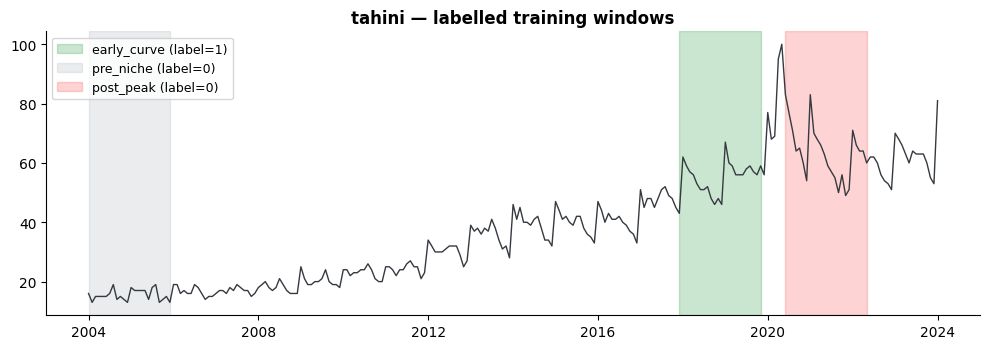

In [4]:
ing = 'tahini'
s = curves[ing]['value']
windows = F.slice_windows(curves[ing])
colors = {'early_curve': '#2f9e44', 'pre_niche': '#adb5bd', 'post_peak': '#fa5252'}

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(s.index, s.values, color='#343a40', lw=1)
for w in windows:
    d = w['data']['value']
    ax.axvspan(d.index[0], d.index[-1], color=colors[w['window_type']], alpha=0.25,
               label=f"{w['window_type']} (label={w['label']})")
ax.set_title(f'{ing} — labelled training windows', fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
fig.tight_layout()
plt.show()

## 3. The feature vectors

Each labelled window collapses into a small, interpretable feature vector: five growth features and three entropy features. This is the table the model actually learns from (built by `python -m src.features`).

| Feature | Meaning |
|---------|---------|
| `growth_rate_6m` / `growth_rate_1y` | % change over the last 6 / 12 months |
| `acceleration` | is the growth rate *itself* increasing? |
| `peak_not_yet_hit` | is the current value still below the window's max? |
| `search_baseline` | average interest in the earliest months (low = was niche) |
| `geographic_entropy` | how spread across regions (low = concentrated in hubs) |
| `temporal_entropy` | how noisy the month-to-month changes are |
| `entropy_delta_6m` | how much temporal entropy dropped recently, the key blip |

In [5]:
feat_df = pd.read_csv(FEATURES_PATH)
print(f'{len(feat_df)} labelled windows  |  positives: {int((feat_df.label==1).sum())}  negatives: {int((feat_df.label==0).sum())}')
cols = ['ingredient', 'window_type', 'label'] + F.FEATURE_COLUMNS
feat_df[cols].round(3)

50 labelled windows  |  positives: 20  negatives: 30


,ingredient,window_type,label,growth_rate_1y,peak_not_yet_hit,search_baseline,geographic_entropy,temporal_entropy,entropy_delta_6m
0,matcha,early_curve,1,0.150,1,66.667,3.830,1.885,-0.492
1,matcha,pre_niche,0,0.000,1,0.833,1.827,1.075,0.099
2,ube,early_curve,1,0.438,1,45.000,3.654,1.662,0.047
3,ube,pre_niche,0,0.111,1,9.167,2.716,1.424,-0.120
4,ube,post_peak,0,-0.012,1,93.667,3.788,2.017,-0.756
5,tahini,early_curve,1,0.224,1,55.000,3.712,1.349,0.310
6,tahini,pre_niche,0,0.000,1,14.833,2.624,1.994,-0.894
7,tahini,post_peak,0,-0.047,1,70.000,3.759,1.546,-0.067
8,kimchi,early_curve,1,-0.014,1,67.500,3.698,1.895,-0.567
9,kimchi,pre_niche,0,0.125,1,5.833,2.391,1.662,-0.098


## 4. The model

Phase 1 is deliberately a **logistic regression**: simple, fast, interpretable. The point isn't raw power; it's a defensible baseline whose coefficients you can read.

The evaluation choice matters more than the model. We use **leave-one-ingredient-out cross-validation**: hold out *every* window of one ingredient, train on the rest, predict the held-out one, repeat. A random row-split would let the model cheat by seeing matcha's pre-niche window in training and its early-curve window in test. Leave-one-ingredient-out answers the real question, which is whether it can judge an ingredient it has never seen.

> **Honest note on the number.** On 50 windows from 20 ingredients this is a deliberately harsh metric. The baseline lands around **0.66 accuracy**, short of the 0.70 target, and we're not dressing that up. Going from the original 10 ingredients (0.58) to 20 vetted ones, then trimming three redundant growth features down to one, took it from 0.58 to 0.66, but with clear diminishing returns: logistic regression on these six features looks close to its ceiling. Crossing 0.70 is what **Phase 2** (a 1D-CNN over the raw curve) was meant to test. This is the floor to beat, not a finished result.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

from src.train import _load_xy

X, y, groups, medians = _load_xy()
logo = LeaveOneGroupOut()
preds, truths = [], []
for tr, te in logo.split(X, y, groups):
    sc = StandardScaler().fit(X[tr])
    clf = LogisticRegression(max_iter=1000, class_weight='balanced').fit(sc.transform(X[tr]), y[tr])
    preds.extend(clf.predict(sc.transform(X[te])))
    truths.extend(y[te])

acc = accuracy_score(truths, preds)
prec = precision_score(truths, preds, zero_division=0)
rec = recall_score(truths, preds, zero_division=0)
print(f'Leave-one-ingredient-out:  accuracy={acc:.2f}  precision={prec:.2f}  recall={rec:.2f}')

Leave-one-ingredient-out:  accuracy=0.66  precision=0.55  recall=0.80


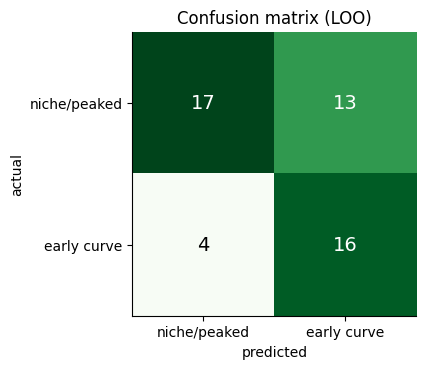

In [7]:
cm = confusion_matrix(truths, preds)
fig, ax = plt.subplots(figsize=(4.2, 3.8))
im = ax.imshow(cm, cmap='Greens')
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha='center', va='center', fontsize=14,
            color='white' if v > cm.max() / 2 else 'black')
ax.set_xticks([0, 1]); ax.set_xticklabels(['niche/peaked', 'early curve'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['niche/peaked', 'early curve'])
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
ax.set_title('Confusion matrix (LOO)')
fig.tight_layout()
plt.show()

### Which features drive the call?

Because it's logistic regression, we can read the coefficients of a model fit on all the data. Positive weight = pushes toward "early curve."

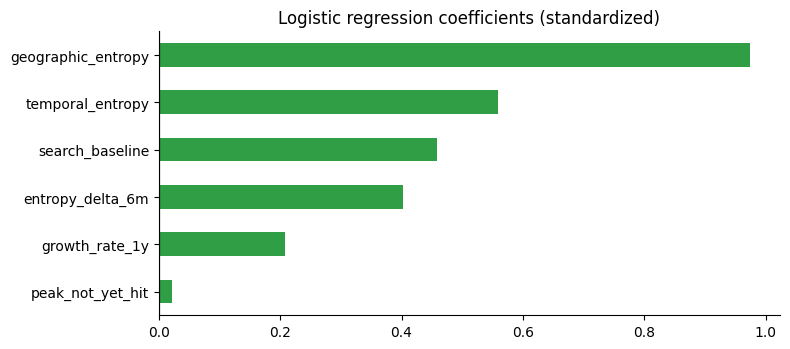

In [8]:
sc = StandardScaler().fit(X)
clf = LogisticRegression(max_iter=1000, class_weight='balanced').fit(sc.transform(X), y)
coef = pd.Series(clf.coef_[0], index=F.FEATURE_COLUMNS).sort_values()

fig, ax = plt.subplots(figsize=(8, 3.6))
coef.plot.barh(ax=ax, color=['#c92a2a' if c < 0 else '#2f9e44' for c in coef])
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Logistic regression coefficients (standardized)')
fig.tight_layout()
plt.show()

> **A note on the growth features.** Originally the model used all three growth features, but they are almost perfectly correlated with each other (`growth_rate_6m`, `growth_rate_1y`, and `acceleration` all sit at r = 0.98 to 0.99, because `acceleration` is essentially built from the growth rates). That redundancy made the coefficients uninterpretable: logistic regression split one underlying signal across them with arbitrary cancelling weights (a strong negative on `acceleration`, a near-zero on `growth_rate_6m`), which looked like "acceleration means not-viral" when it didn't.

> We fixed it by keeping only `growth_rate_1y` and dropping the other two. That removed the collinearity (max correlation among the remaining features falls to 0.53), and it actually nudged leave-one-ingredient-out accuracy up from 0.64 to 0.66 while making every coefficient sign intuitive. The chart above is the cleaned-up six-feature model: `geographic_entropy` is the strongest signal, the entropy family carries most of the weight, and `growth_rate_1y` is a sensible positive. The dropped features are still computed and stored in `features.csv` for inspection; the model just doesn't train on them.

### Limitations: how much to trust these numbers

Three honest caveats, because n = 20 ingredients is small and we should not over-claim.

1. **The 0.66 is mildly optimistic.** Over the course of this work we changed the dataset (10 to 20 ingredients, dropped two mislabeled positives) and trimmed the features, checking the leave-one-ingredient-out score along the way. Even with principled changes, repeatedly evaluating against the *same* 20-ingredient holdout means we have implicitly fit to that particular set. A truly clean estimate would come from a fresh batch of ingredients we have never scored against. Read 0.66 as an upper-ish estimate, not a guarantee.

2. **Small-sample noise swamps small differences.** With 20 groups, the leave-one-ingredient-out score wobbles by roughly plus or minus 0.02 to 0.03 fold to fold (you can see it in the learning-curve band). So 0.66 vs 0.64 vs the CNN's 0.62 are probably **not statistically distinguishable**. We can say the CNN didn't beat the baseline and that the simpler model holds up; we should *not* claim '6 features beats 8' or '0.66 beats 0.64' as a robust fact. Those are suggestive, not proven.

3. **The labels are human judgment.** Which ingredients 'went viral,' and which 24 months count as the 'early curve,' were our calls. They're defensible and consistently applied, but they are not ground truth.

None of this is fatal, and none of it is hidden. It's the normal reality of a small, noisy problem. The honest summary: the *process* is sound (no leakage, real holdout, results reported as-is), and the *conclusions* are directional rather than precise. That's exactly what a radar, not a crystal ball, should claim.

## 5. The demo: diagnosing rising ingredients

Now the payoff. We run the full diagnosis on three ingredients that are *rising but not yet mainstream* (pandan, butterfly pea flower, calamansi), none of which the model was trained on. For each we fetch a recent window, extract the same features, score it, and map the result to a lifecycle stage with a one-line rationale.

Stages: **No signal · Stage 1 Entropy Drop · Stage 2 Momentum · Stage 3 Resonance**

The stage is gated by the model probability, so a noisy uptick on a curve that *doesn't* look early-viral is reported as "No signal," not falsely promoted to "Momentum." So the stage always agrees with the model's confidence.

> This cell makes live `pytrends` calls (cached after the first run). Google rate-limits aggressive use; if you hit a 429, set a valid `NID` browser cookie via the `TRENDS_NID` environment variable, or drop a manual CSV export at the path the error names, then re-run.

Pandan — Stage 2 — Momentum
    Match 51% and growth accelerating (accel=+0.10); early-mover window. (match 51%)



Butterfly Pea Flower — No signal
    Doesn't match an early-viral curve (match 16%) — still noise. (match 16%)

Calamansi — No signal
    Doesn't match an early-viral curve (match 39%) — still noise. (match 39%)



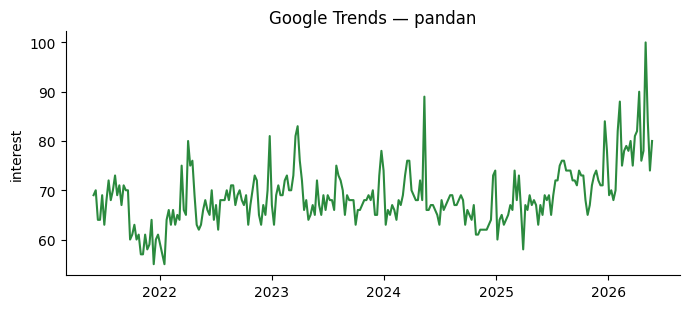

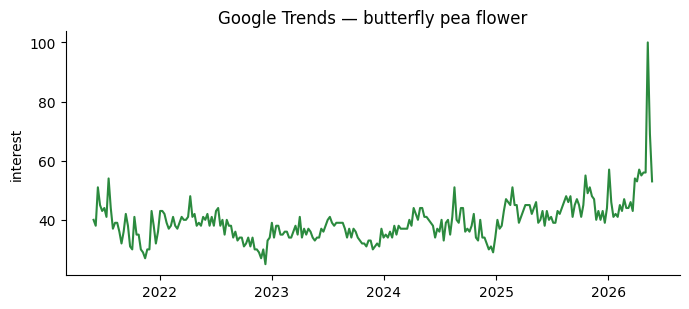

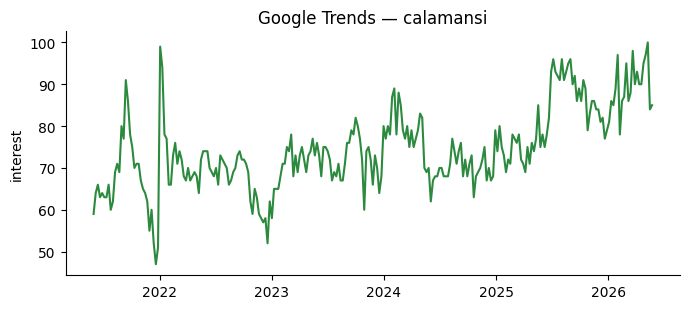

In [9]:
from src.diagnose import diagnose

targets = ['pandan', 'butterfly pea flower', 'calamansi']
results = {}
for ing in targets:
    try:
        headline, rationale, prob, chart = diagnose(ing)
        results[ing] = (headline, rationale, prob, chart)
        print(headline)
        print('   ', rationale, f'(match {prob:.0%})')
    except Exception as e:
        print(f'{ing}: could not diagnose — {e}')
    print()

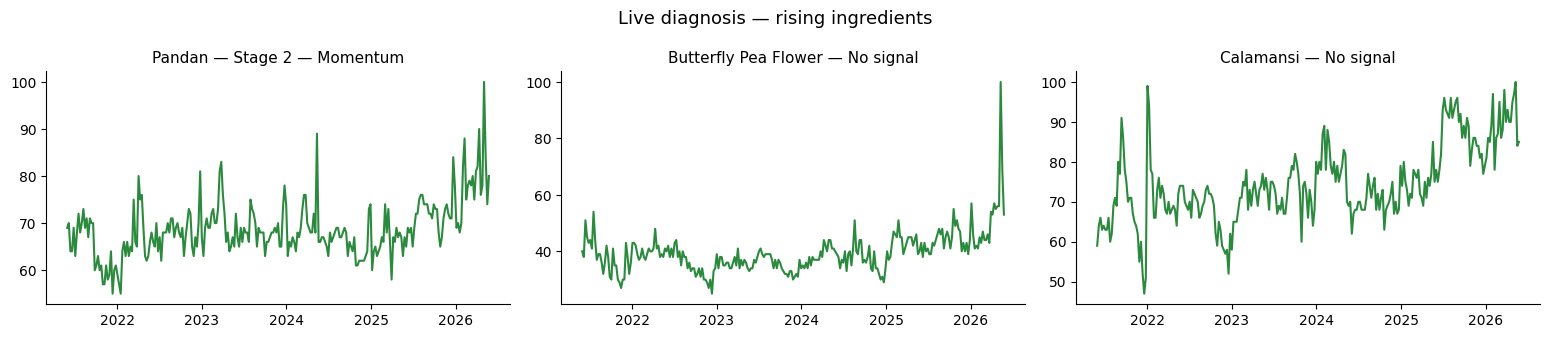

In [10]:
# Show each diagnosed ingredient's trend curve alongside its verdict.
ok = list(results.items())
if ok:
    fig, axes = plt.subplots(1, len(ok), figsize=(5.2 * len(ok), 3.4), squeeze=False)
    for ax, (ing, (headline, rationale, prob, _)) in zip(axes[0], ok):
        s = fetch_interest_over_time(ing, timeframe='today 5-y', tag='demo')['value']
        ax.plot(s.index, s.values, color='#2b8a3e')
        ax.set_title(headline, fontsize=11)
    fig.suptitle('Live diagnosis — rising ingredients', fontsize=13)
    fig.tight_layout()
    plt.show()
else:
    print('No live results to plot (likely rate-limited). Re-run section 5 after the limit clears.')

## 6. Would more data get us to 0.70? A learning curve

The baseline lands at ~0.66 accuracy, short of the brief's 0.70 target. The obvious
question: would simply collecting **more ingredients** push it over the line?

There are two very different reasons a model can stall:

- **Data-limited.** There isn't *enough* data yet; the accuracy curve is still climbing,
  and more examples would keep lifting it.
- **Signal-limited.** The features have already captured about as much as they contain;
  adding more of the same data just confirms the same ceiling.

We can tell these apart empirically with a **learning curve**: re-run the exact
leave-one-ingredient-out evaluation on growing subsets of ingredients (6, 8, … 20),
averaging over several random subsets at each size so the result isn't an artifact of
*which* ingredients happen to come first. If accuracy is still rising at 20, we're
data-limited. If it has flattened, we're signal-limited.

The cell below computes and plots that curve (mean accuracy with a shaded ±1 std band;
the dashed line marks the 0.70 target).

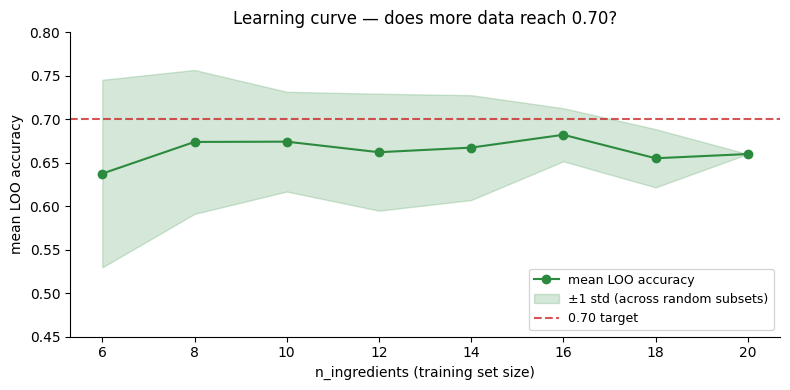

size  mean_acc  std
   6    0.637   0.108
   8    0.674   0.083
  10    0.674   0.057
  12    0.662   0.067
  14    0.667   0.060
  16    0.682   0.031
  18    0.655   0.034
  20    0.660   0.000


In [11]:
from sklearn.model_selection import LeaveOneGroupOut

def _loo_accuracy(sub_df):
    """LOO accuracy for a subset of ingredients (same protocol as the main model)."""
    feats = sub_df[F.FEATURE_COLUMNS].astype(float)
    feats = feats.fillna(feats.median(numeric_only=True).fillna(0.0))
    Xs = feats.to_numpy(float); ys = sub_df['label'].to_numpy(int)
    gs = sub_df['ingredient'].to_numpy()
    if len(set(gs)) < 3 or len(set(ys)) < 2:
        return None
    P, T = [], []
    for tr, te in LeaveOneGroupOut().split(Xs, ys, gs):
        if len(set(ys[tr])) < 2:
            continue
        sc = StandardScaler().fit(Xs[tr])
        clf = LogisticRegression(max_iter=1000, class_weight='balanced').fit(sc.transform(Xs[tr]), ys[tr])
        P.extend(clf.predict(sc.transform(Xs[te]))); T.extend(ys[te])
    return accuracy_score(T, P) if T else None

feat_df = pd.read_csv(FEATURES_PATH)
all_ings = list(feat_df['ingredient'].unique())
n_total = len(all_ings)
curve_rng = np.random.default_rng(0)

sizes = [n for n in [6, 8, 10, 12, 14, 16, 18, 20] if n <= n_total]
means, stds = [], []
for n in sizes:
    trials = 1 if n == n_total else 12   # average random subsets, except at full size
    accs = []
    for _ in range(trials):
        chosen = list(curve_rng.choice(all_ings, size=n, replace=False))
        a = _loo_accuracy(feat_df[feat_df.ingredient.isin(chosen)])
        if a is not None:
            accs.append(a)
    means.append(np.mean(accs)); stds.append(np.std(accs))

means, stds = np.array(means), np.array(stds)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sizes, means, marker='o', color='#2b8a3e', label='mean LOO accuracy')
ax.fill_between(sizes, means - stds, means + stds, color='#2b8a3e', alpha=0.2,
                label='±1 std (across random subsets)')
ax.axhline(0.70, ls='--', color='#c92a2a', alpha=0.8, label='0.70 target')
ax.set_xlabel('n_ingredients (training set size)')
ax.set_ylabel('mean LOO accuracy')
ax.set_title('Learning curve — does more data reach 0.70?')
ax.set_ylim(0.45, 0.80)
ax.legend(loc='lower right', fontsize=9)
fig.tight_layout()
plt.show()

print('size  mean_acc  std')
for n, m, s in zip(sizes, means, stds):
    print(f'{n:>4}    {m:.3f}   {s:.3f}')

### What the curve shows: signal-limited, not data-limited

The accuracy climbs from the very small sizes (where it's also wildly variable) up to about 10 ingredients, then flattens in the mid-0.60s and stays there. It does not keep rising toward the 0.70 line as the training set grows from 10 to 20. Meanwhile the shaded band narrows steadily: more data isn't lifting the *accuracy*, but it *is* making the estimate more reliable (tighter error bars).

A flat learning curve is the signature of a signal-limited model, not a data-limited one. The features have already extracted about as much separating power as they contain, so feeding in more ingredients mostly adds more of the same and confirms the same ceiling. Crossing 0.70 would more likely require richer features or a different signal source, not simply more rows.

This is an honest and frankly expected result given the domain. As the project brief puts it, food trends are "noisier than the stock market... ube went viral partly because it photographs beautifully," and there are no fundamentals to anchor a forecast. A transparent mid-0.60s radar whose limits are measured and disclosed is more trustworthy than a 0.70 reached by overfitting a tiny dataset. We diagnose where an ingredient sits, we don't pretend to a precision the signal can't support.

## Takeaways

- NextOnMenu diagnoses lifecycle stage, it doesn't predict virality, which is a more honest and more defensible question.
- The entropy framing (organization, then momentum, then resonance) gives the model features that go beyond "is it growing," capturing *how* it's growing.
- The logistic-regression baseline with leave-one-ingredient-out evaluation is intentionally simple and interpretable; it's the floor, not the ceiling. Phase 2 (LSTM / 1D CNN over raw curves) is the natural next step.
- The honest framing for the killer question: "pandan is where matcha was in 2015," not "pandan will go viral."

*Radar, not crystal ball.*